In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Import libraries for machine learning

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from IPython.display import Image

In [3]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_csv("Delhi+Delights+Data.csv")

In [18]:
# See head of the df

df.head()

,Average Delivery Rating (a1),Average Orders per month (a2),"""Delighted Members"" Purchase"
0,1.5,11,Yes
1,2.5,11,No
2,2.5,11,No
3,3.5,11,No
4,3.5,11,No


In [19]:
# See the shape
df.shape

(30, 3)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Average Delivery Rating (a1)   30 non-null     float64
 1   Average Orders per month (a2)  30 non-null     int64  
 2   "Delighted Members" Purchase   30 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


In [21]:
# See the details
df.describe()

,Average Delivery Rating (a1),Average Orders per month (a2)
count,30.000000,30.000000
mean,3.066667,21.000000
std,1.040004,10.763924
min,1.500000,11.000000
25%,2.500000,13.000000
50%,3.000000,15.000000
75%,3.500000,27.000000
max,4.500000,39.000000


In [22]:
df.columns

Index(['Average Delivery Rating (a1)', 'Average Orders per month (a2)',
       '"Delighted Members" Purchase'],
      dtype='object')

In [23]:
# Check null values

df.isnull().sum()

Average Delivery Rating (a1)     0
Average Orders per month (a2)    0
"Delighted Members" Purchase     0
dtype: int64

In [24]:
# Renaming a few columns for better readibility.

df.rename(columns={
        'Average Delivery Rating (a1)': 'average_delivery_ratings',
        'Average Orders per month (a2)': 'average_orders_per_month',
        '"Delighted Members" Purchase': 'delighted_members_purchase'}, inplace=True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   average_delivery_ratings    30 non-null     float64
 1   average_orders_per_month    30 non-null     int64  
 2   delighted_members_purchase  30 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


In [26]:
df.average_delivery_ratings.value_counts()

average_delivery_ratings
2.5    10
3.5     8
4.5     7
1.5     5
Name: count, dtype: int64

In [27]:
df.average_orders_per_month.value_counts()

average_orders_per_month
11    6
13    6
15    6
27    6
39    6
Name: count, dtype: int64

In [28]:
df.delighted_members_purchase.value_counts()

delighted_members_purchase
Yes    15
No     15
Name: count, dtype: int64

In [29]:
df.delighted_members_purchase.replace({'Yes': 1, 'No': 0}, inplace = True)

In [30]:
df.delighted_members_purchase.value_counts()

delighted_members_purchase
1    15
0    15
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   average_delivery_ratings    30 non-null     float64
 1   average_orders_per_month    30 non-null     int64  
 2   delighted_members_purchase  30 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes


In [32]:
X = df.drop(['delighted_members_purchase'], axis = 1)
y = df['delighted_members_purchase']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 42)

In [49]:
X_train.shape

(21, 2)

In [50]:
X_test.shape

(9, 2)

In [51]:
y_train.shape

(21,)

In [52]:
y_test.shape

(9,)

In [66]:
dt = DecisionTreeClassifier(max_depth = 5, min_samples_split = 10, min_samples_leaf = 5)

In [67]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10)

[Text(0.6, 0.8333333333333334, 'x[1] <= 21.0\ngini = 0.499\nsamples = 21\nvalue = [11, 10]'),
 Text(0.4, 0.5, 'x[1] <= 12.0\ngini = 0.355\nsamples = 13\nvalue = [10, 3]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.8, 0.5, 'gini = 0.219\nsamples = 8\nvalue = [1, 7]')]

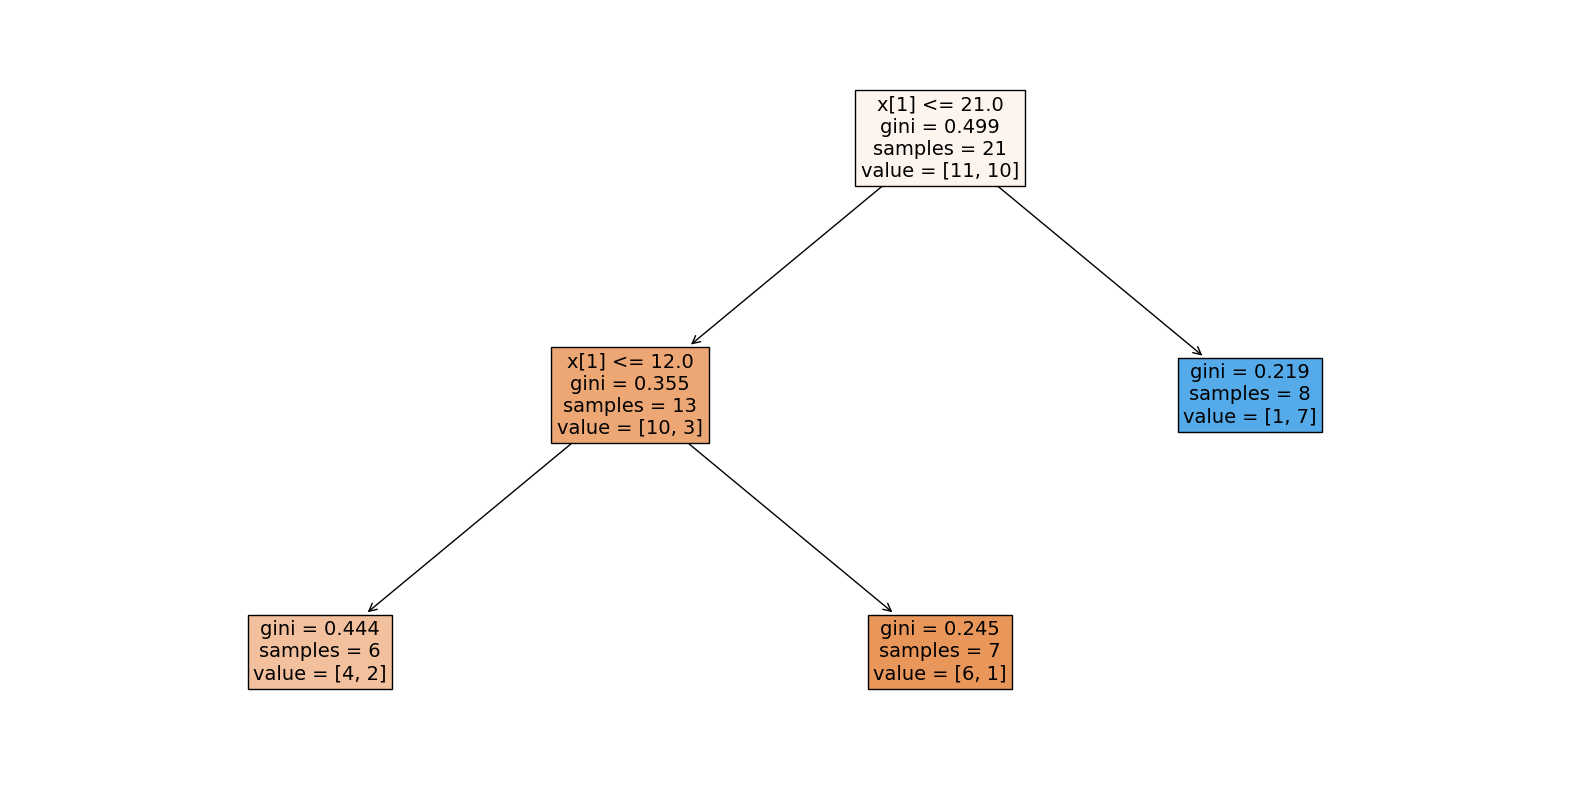

In [68]:
plt.figure(figsize=(20,10))
tree.plot_tree(dt, filled=True, fontsize=14)